# Milestone 1 Notebook: Data Collection, EDA, and Hypothesis Testing

This notebook documents the **14 April milestone** of the Faker project for DSA210.
It combines short explanations, code, plots, and formal hypothesis-test results in one readable place.

**Research question:**  
Does Faker have more stable performance than a small comparison group of elite professional League of Legends mid-lane players after major game updates, and is that associated with champion-pool diversity?


## Background

- **League of Legends** is a five-versus-five competitive video game with frequent updates.
- These updates are called **patches**.
- A **champion** is a playable character.
- **Champion-pool diversity** refers to the variety of champions a player can use effectively in professional matches.
- The project focuses on **Faker** and compares him with a small benchmark group of elite mid-lane players.


## Data sources

This milestone uses two public sources:

1. **Oracle's Elixir** professional match exports for match-level player statistics.
2. **Riot champion metadata** in `champions_simple.json` to attach broad champion style tags.

The tables used in the notebook are the processed outputs already saved in `data/processed/`.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "processed").exists():
            return path
    raise FileNotFoundError("Could not locate project root with data/processed directory.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"

mid = pd.read_csv(DATA_DIR / "processed" / "mid_players_2024.csv", parse_dates=["date"])
patch = pd.read_csv(DATA_DIR / "processed" / "player_patch_summary.csv", parse_dates=["patch_date"])
tests = pd.read_csv(DATA_DIR / "processed" / "hypothesis_tests.csv")
overall = pd.read_csv(DATA_DIR / "processed" / "overall_player_summary.csv")

print("Match-level rows:", len(mid))
print("Patch summary rows:", len(patch))
print("Players:", ", ".join(sorted(mid["player_name"].unique())))
print("Patches studied:", ", ".join(sorted(patch["patch"].astype(str).unique())))


Match-level rows: 732
Patch summary rows: 18
Players: Bdd, Caps, Chovy, Faker, ShowMaker, knight
Patches studied: 14.13, 14.16, 14.5


## Sample overview


In [2]:
sample_overview = pd.DataFrame({
    "Metric": [
        "Time period",
        "Players",
        "Leagues/tournaments",
        "Match-level rows",
        "Patch windows"
    ],
    "Value": [
        f"{mid['date'].min().date()} to {mid['date'].max().date()}",
        ", ".join(sorted(mid["player_name"].unique())),
        ", ".join(sorted(mid["league_name"].dropna().unique())),
        len(mid),
        ", ".join(sorted(patch["patch"].astype(str).unique()))
    ]
})
display(sample_overview)


,Metric,Value
0,Time period,2024-01-03 to 2024-09-14
1,Players,"Bdd, Caps, Chovy, Faker, ShowMaker, knight"
2,Leagues/tournaments,"Demacia Cup, Esports World Cup, LCK, LEC, LPL,..."
3,Match-level rows,732
4,Patch windows,"14.13, 14.16, 14.5"


## Match-level data preview

Each row below represents one professional player in one professional match.


In [3]:
preview_cols = [
    "date", "player_name", "team_name", "league_name",
    "champion_name", "primary_tag", "player_kills", "player_deaths", "player_assists",
    "kda", "cs_per_min", "dmg_per_min", "gold_per_min", "kp", "performance_index"
]
display(mid[preview_cols].head(10))


,date,player_name,team_name,league_name,champion_name,primary_tag,player_kills,player_deaths,player_assists,kda,cs_per_min,dmg_per_min,gold_per_min,kp,performance_index
0,2024-01-03 09:08:32.430000,knight,Bilibili Gaming,Demacia Cup,Tristana,Marksman,4,1,4,8.000000,9.193846,668.381538,427.384615,0.500000,-0.038934
1,2024-01-03 09:54:00.478000,knight,Bilibili Gaming,Demacia Cup,Orianna,Mage,3,2,7,5.000000,8.681948,562.521490,408.223496,0.526316,-0.327299
2,2024-01-03 10:35:15.933000,knight,Bilibili Gaming,Demacia Cup,Tristana,Marksman,10,3,6,5.333333,8.946396,1023.327172,532.791128,0.571429,0.456069
3,2024-01-06 09:16:15.868000,knight,Bilibili Gaming,Demacia Cup,Neeko,Mage,2,6,10,2.000000,7.850467,580.505772,388.070368,0.666667,-0.474937
4,2024-01-06 10:06:55.895000,knight,Bilibili Gaming,Demacia Cup,Ahri,Mage,9,0,9,18.000000,9.365645,864.248040,529.137562,0.857143,1.077569
5,2024-01-06 10:49:28.062000,knight,Bilibili Gaming,Demacia Cup,Akali,Assassin,11,1,7,18.000000,8.148148,652.206119,470.370370,0.857143,0.565420
6,2024-01-13 16:05:40.125000,Caps,G2 Esports,LEC,Neeko,Mage,2,0,7,9.000000,9.639794,551.012007,432.555746,0.642857,0.122574
7,2024-01-14 18:49:28.371868,Caps,G2 Esports,LEC,LeBlanc,Assassin,3,2,3,3.000000,10.005195,556.831169,450.420779,0.400000,-0.185771
8,2024-01-15 17:01:29.311913,Caps,G2 Esports,LEC,Neeko,Mage,0,6,3,0.500000,8.681416,385.168142,380.946903,0.500000,-1.060469
9,2024-01-17 11:00:30.480829,Chovy,Gen.G,LCK,Corki,Marksman,2,1,2,4.000000,9.212191,635.434158,415.756182,1.000000,-0.126447


## Player-level summary

This table aggregates the season for each player and gives a quick overview of overall performance, variability, and champion variety.


In [4]:
display(overall.sort_values("player_name").round(3))


,player_name,games,leagues,winrate,avg_kda,avg_perf,perf_std,unique_champions,champion_entropy
5,Bdd,105,LCK,0.524,6.382,-0.100,0.683,18,3.542
1,Caps,107,"Esports World Cup, LEC, Mid-Season Invitational",0.710,6.307,0.063,0.604,21,3.783
0,Chovy,121,"Esports World Cup, LCK, Mid-Season Invitational",0.810,7.203,0.405,0.579,21,3.427
2,Faker,159,"Esports World Cup, LCK, Mid-Season Invitational",0.629,5.360,-0.166,0.621,22,3.421
3,ShowMaker,115,LCK,0.539,5.838,-0.221,0.664,25,4.010
4,knight,125,"Demacia Cup, Esports World Cup, LPL, Mid-Seaso...",0.736,7.759,0.052,0.677,23,4.012


## Exploratory data analysis

The main exploratory question is whether Faker appears more stable than peers around patch transitions, and whether that may relate to champion diversity.


### Rolling performance through the season


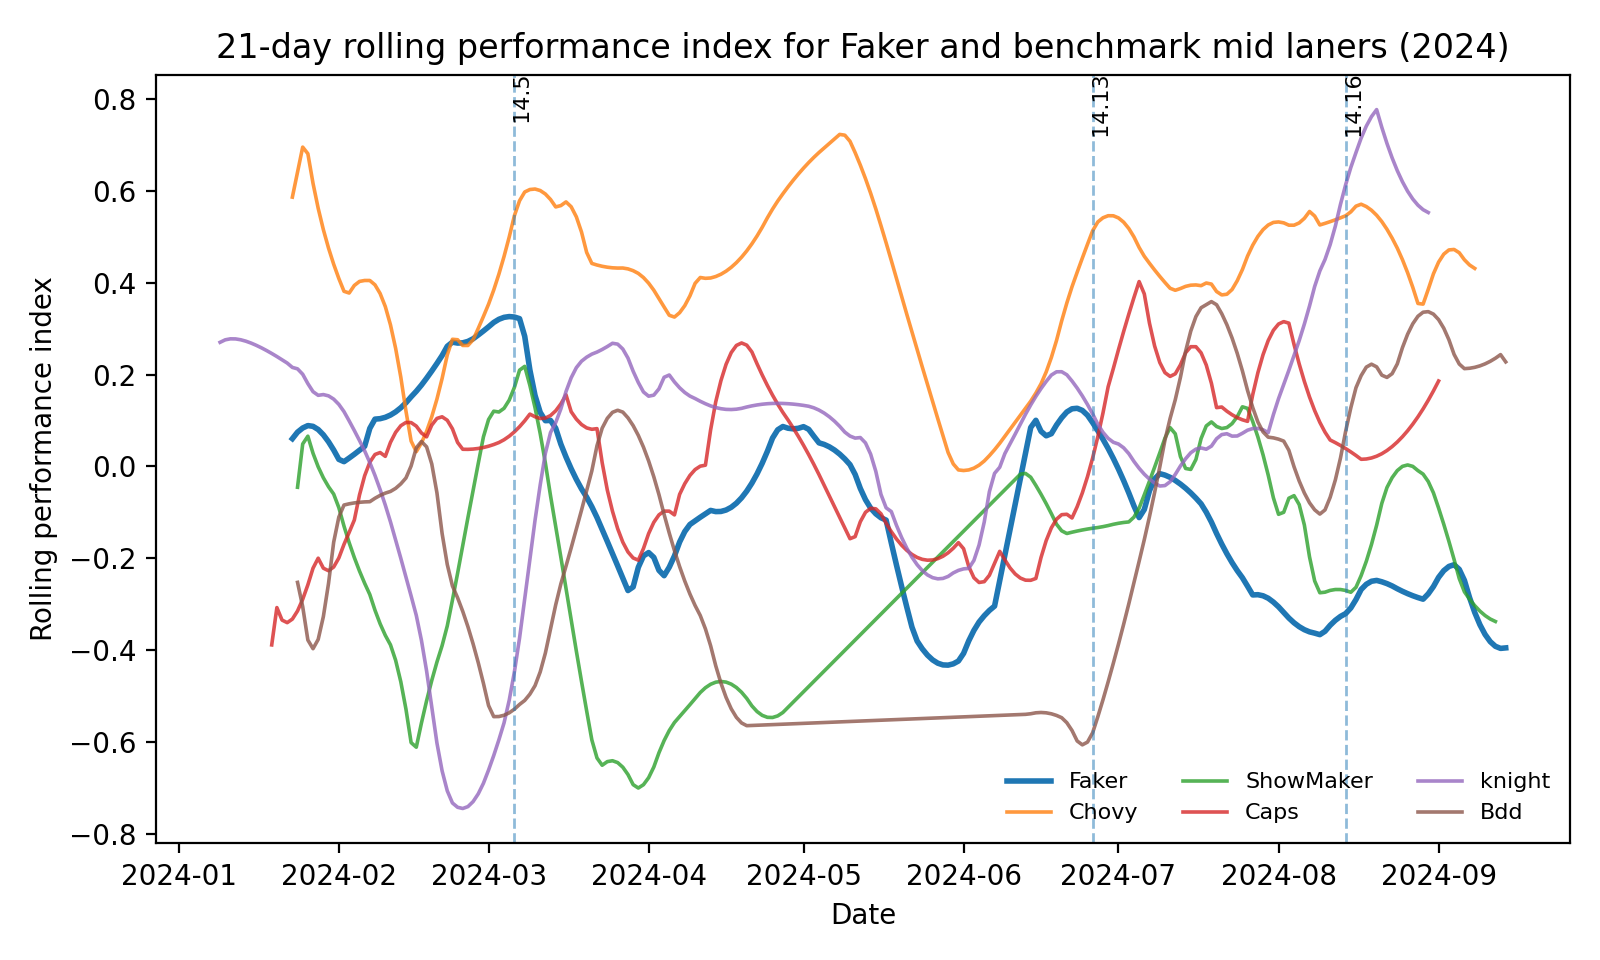

In [5]:
display(Image(filename=str(FIG_DIR / "rolling_performance_2024.png")))


**Interpretation:** performance varies over time for all players. Faker remains competitive throughout the season, but he is not always the single best performer in every period.


### Average absolute performance change across patch windows


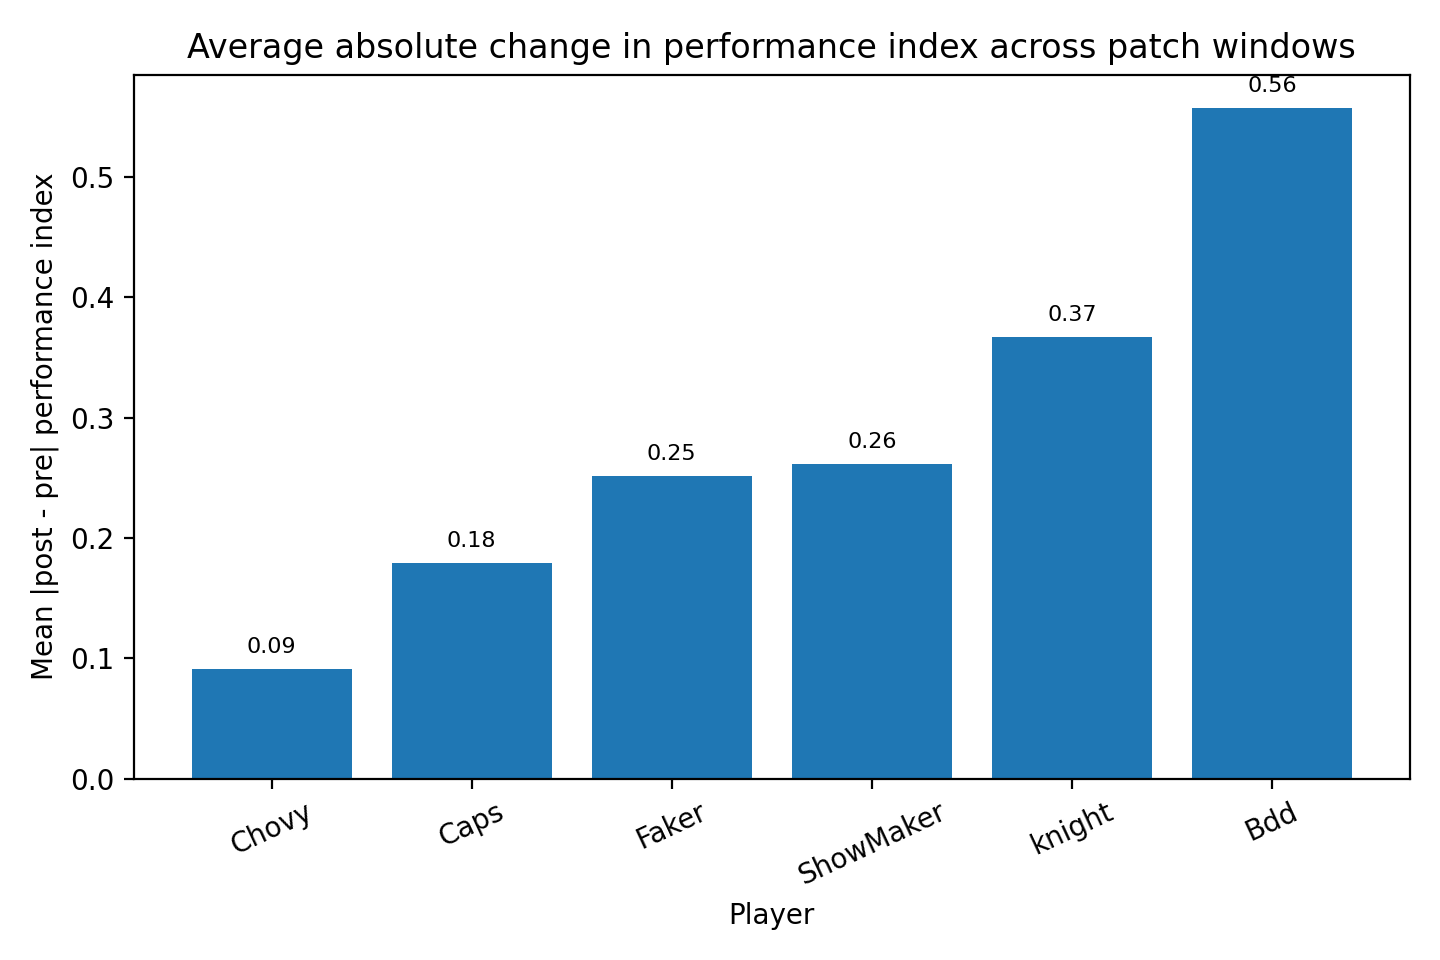

In [6]:
display(Image(filename=str(FIG_DIR / "avg_abs_patch_change.png")))


**Interpretation:** smaller values indicate more stable performance before versus after patches. Faker's average absolute change is lower than the peer average in this sample.


### Diversity versus stability


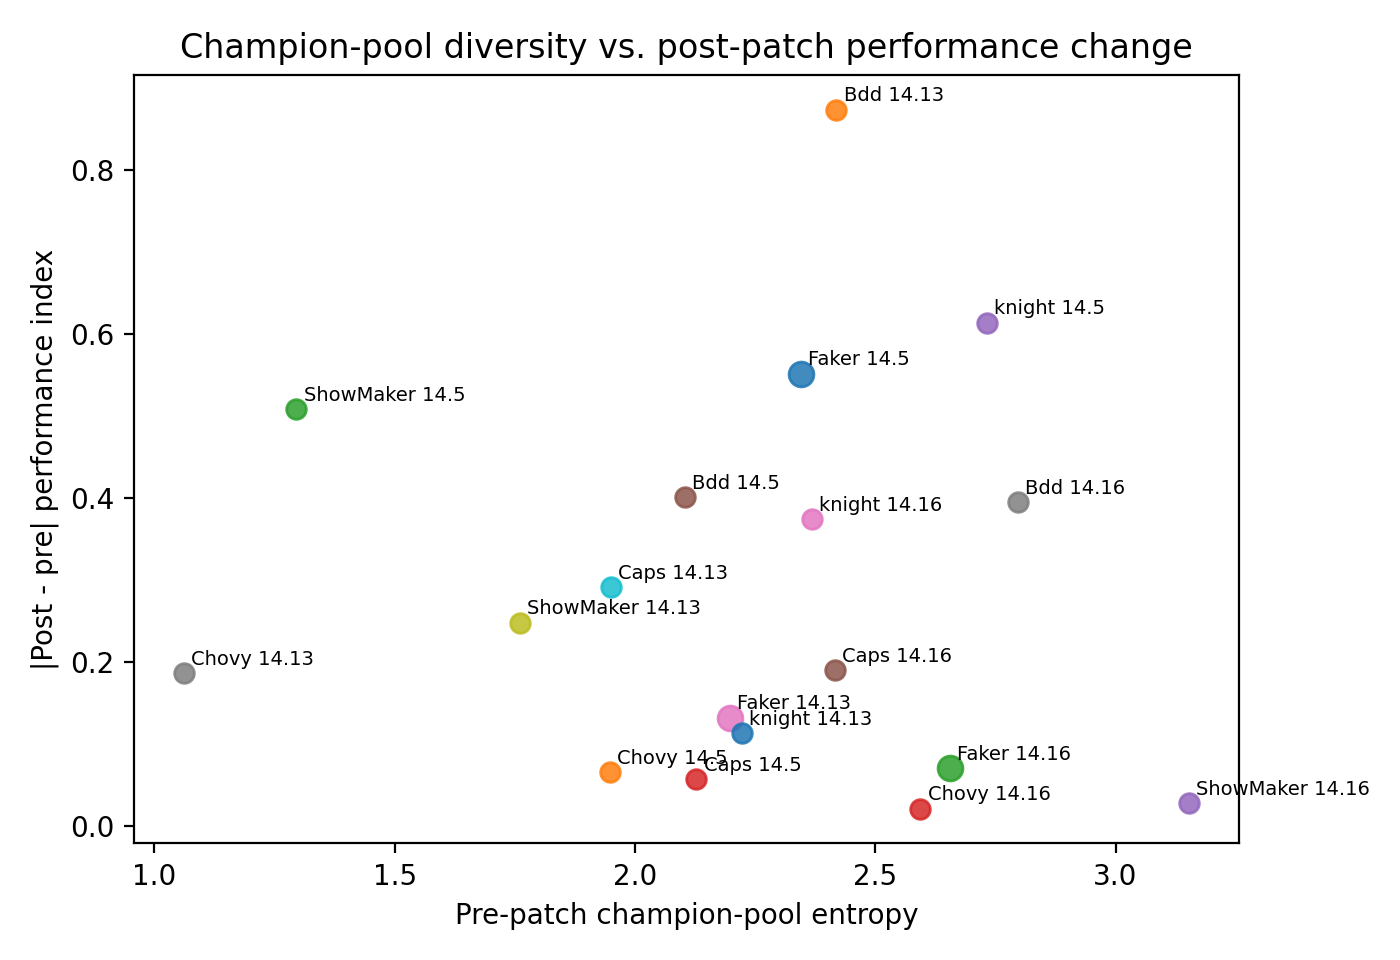

In [7]:
display(Image(filename=str(FIG_DIR / "diversity_vs_stability.png")))


**Interpretation:** the relationship is not strongly monotonic in the current sample. The figure does not show clear evidence that higher diversity alone guarantees more stability.


### New champion rate after patches


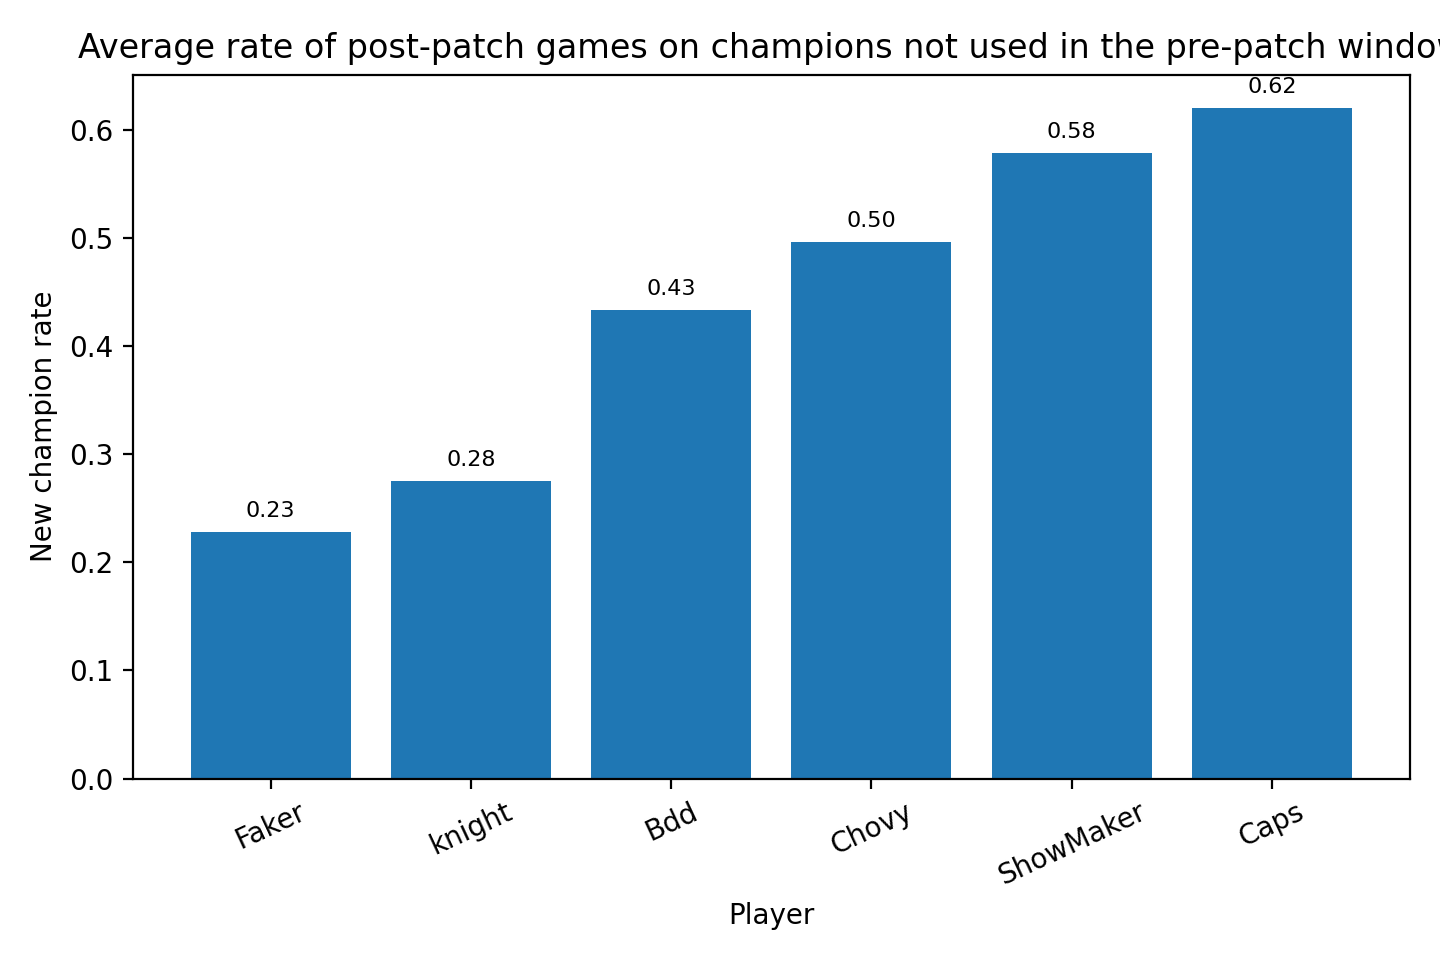

In [8]:
display(Image(filename=str(FIG_DIR / "new_champion_rate.png")))


**Interpretation:** Faker uses fewer completely new champions right after patches than the peer group, which suggests a slightly more conservative adaptation strategy.


### Champion style distribution


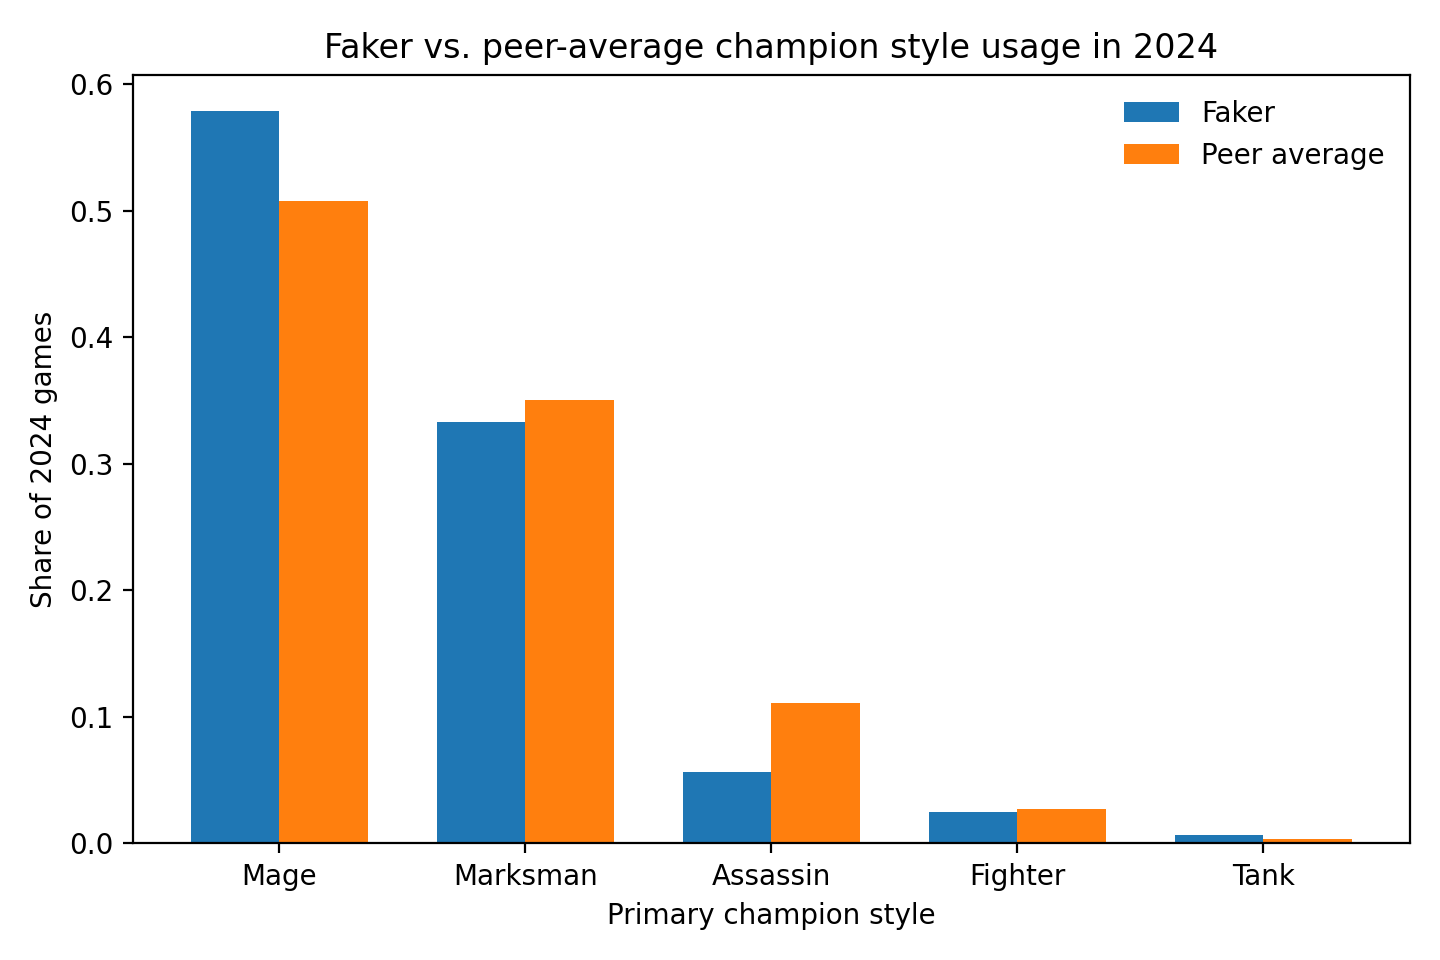

In [9]:
display(Image(filename=str(FIG_DIR / "style_share_faker_vs_peers.png")))


### Patch-by-patch change heatmap


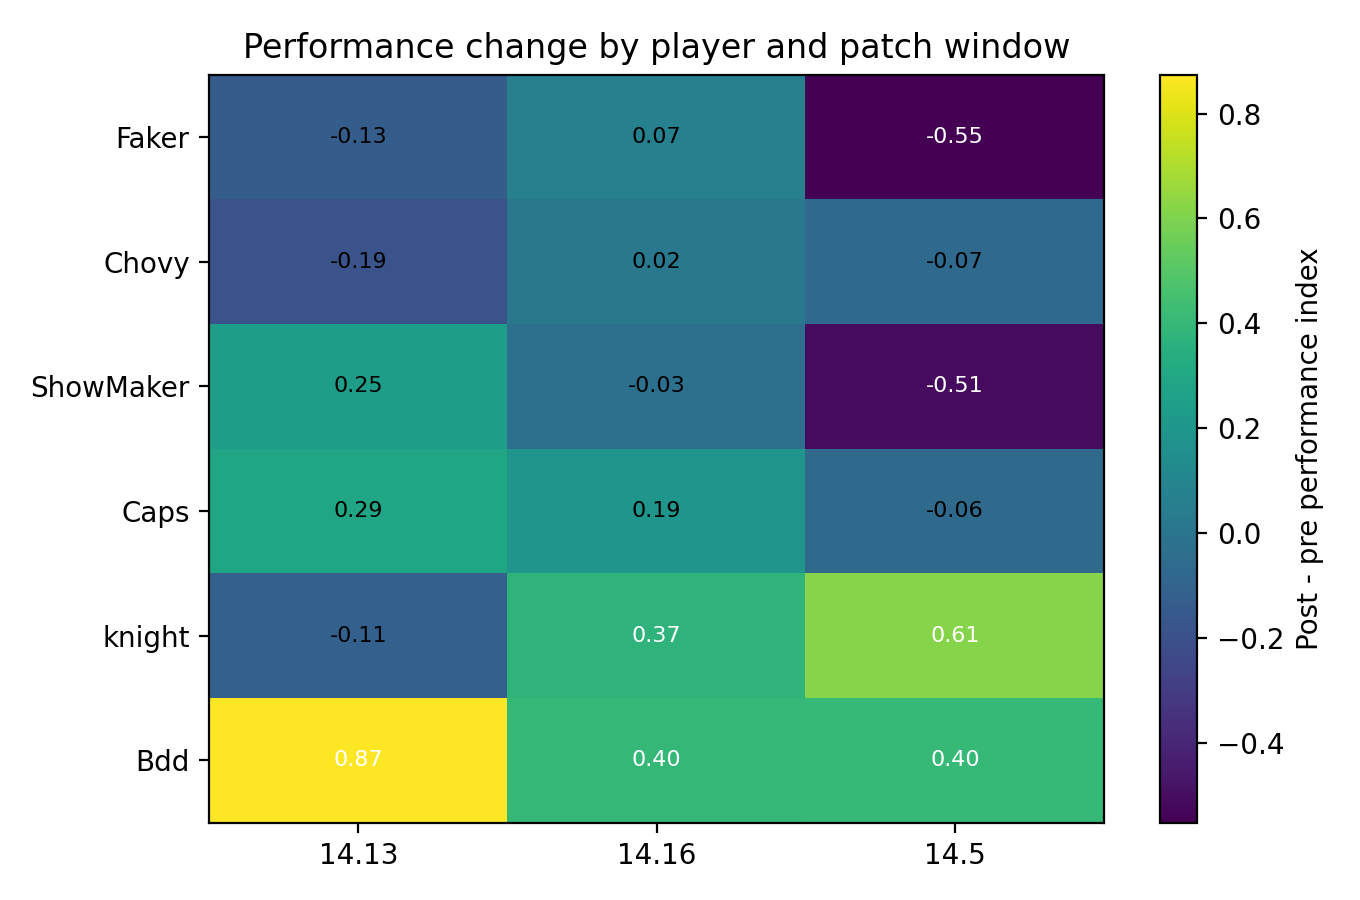

In [10]:
display(Image(filename=str(FIG_DIR / "patch_delta_heatmap.png")))


## Patch summary table

Each row below compares one player's average pre-patch and post-patch behavior around a major update.


In [11]:
display(patch.round(3))


,patch,patch_date,player_name,pre_games,post_games,pre_perf,post_perf,delta_perf,abs_delta_perf,pre_winrate,post_winrate,pre_diversity_unique,pre_diversity_entropy,post_diversity_unique,post_diversity_entropy,new_champion_rate,pre_primary_styles,post_primary_styles
0,14.50,2024-03-06,Bdd,13,20,-0.450,-0.049,0.402,0.402,0.385,0.650,5,2.104,9,2.966,0.500,"Mage, Marksman","Mage, Marksman"
1,14.50,2024-03-06,Caps,7,13,0.010,-0.047,-0.057,0.057,0.857,0.769,5,2.128,7,2.624,0.923,"Assassin, Mage, Tank",Mage
2,14.50,2024-03-06,Chovy,12,13,0.439,0.373,-0.065,0.065,0.833,0.923,6,1.947,9,3.027,0.769,"Assassin, Mage, Marksman","Assassin, Mage, Marksman"
3,14.50,2024-03-06,Faker,13,13,0.308,-0.244,-0.552,0.552,0.923,0.692,6,2.346,7,2.354,0.308,"Mage, Marksman","Assassin, Mage, Marksman"
4,14.50,2024-03-06,ShowMaker,13,19,0.016,-0.492,-0.508,0.508,0.769,0.421,3,1.296,9,2.945,0.632,"Assassin, Mage","Assassin, Mage, Marksman"
5,14.50,2024-03-06,knight,11,13,-0.328,0.286,0.614,0.614,0.727,0.923,7,2.732,5,2.134,0.077,"Assassin, Mage","Assassin, Mage"
6,14.13,2024-06-26,Bdd,9,15,-0.656,0.218,0.874,0.874,0.111,0.733,6,2.419,5,1.963,0.800,"Assassin, Fighter, Mage, Marksman","Mage, Marksman"
7,14.13,2024-06-26,Caps,7,16,-0.128,0.164,0.292,0.292,0.714,0.625,4,1.950,5,2.180,0.438,"Mage, Marksman","Assassin, Marksman"
8,14.13,2024-06-26,Chovy,8,15,0.615,0.429,-0.187,0.187,1.000,0.800,3,1.061,6,2.333,0.533,"Assassin, Marksman","Assassin, Mage, Marksman"
9,14.13,2024-06-26,Faker,9,26,0.014,-0.118,-0.132,0.132,0.667,0.538,5,2.197,7,2.158,0.077,"Mage, Marksman","Fighter, Mage, Marksman"


## Hypothesis tests

Four hypotheses were tested:

1. Faker shows smaller absolute post-patch performance changes than peers.
2. Faker has greater pre-patch champion-pool diversity than peers.
3. Greater pre-patch diversity is associated with smaller post-patch performance changes.
4. Faker uses fewer truly new champions immediately after patches than peers.


In [12]:
display(tests.round(4))


,hypothesis,test,statistic,value,p_value,faker_mean,peer_mean
0,H1 Faker has smaller average absolute post-pat...,Permutation test (one-sided),mean difference (Faker - peers),-0.0398,0.4355,0.2514,0.2912
1,H2 Faker has higher pre-patch champion-pool di...,Permutation test (one-sided),mean entropy difference (Faker - peers),0.2027,0.2850,2.3994,2.1966
2,H3 Higher pre-patch champion-pool diversity is...,Spearman correlation,rho,-0.0382,0.8804,NaN,NaN
3,H4 Faker uses fewer truly new champions immedi...,Permutation test (one-sided),mean difference (Faker - peers),-0.2527,0.0631,0.2282,0.4809


## Key numerical comparisons


In [13]:
faker_rows = patch[patch["player_name"] == "Faker"]
peer_rows = patch[patch["player_name"] != "Faker"]

summary_table = pd.DataFrame({
    "Metric": [
        "Mean absolute patch change",
        "Mean pre-patch diversity entropy",
        "Mean new champion rate"
    ],
    "Faker": [
        faker_rows["abs_delta_perf"].mean(),
        faker_rows["pre_diversity_entropy"].mean(),
        faker_rows["new_champion_rate"].mean()
    ],
    "Peers": [
        peer_rows["abs_delta_perf"].mean(),
        peer_rows["pre_diversity_entropy"].mean(),
        peer_rows["new_champion_rate"].mean()
    ]
}).round(3)

display(summary_table)


,Metric,Faker,Peers
0,Mean absolute patch change,0.251,0.291
1,Mean pre-patch diversity entropy,2.399,2.197
2,Mean new champion rate,0.228,0.481


## Milestone 1 conclusion

The evidence supports a **tentative** conclusion:

- Faker appears slightly more stable than peers in average post-patch performance change.
- Faker also shows slightly higher champion-pool diversity in the pre-patch windows.
- The strongest pattern in the sample is that Faker uses fewer truly new champions immediately after patches.

However, the current milestone sample does **not** provide strong statistical evidence for the broader claim.
The results are promising, but still limited by sample size and by the narrow focus on six elite players across three patch windows.


## Reproducibility

The processed files and figures displayed here are generated by:

```bash
python scripts/run_milestone_analysis.py
```
